# Лабораторная 1. Классификация растровых изображений с помощью kNN

**Задание.** Написать программу для распознавания растровых изображений, используя
метод ближайшего соседа. Реализовать программно равномерное и неравномерное
зашумление изображений и сравнить процент распознавания для используемых норм в
случаях распознавания растровых бинарных изображений и изображений в градациях
серого цвета для различных `k`. Сравнить результаты применения разных
мер близости.

## 1. Теория

### Метод ближайшего соседа

Дана обучающая выборка $\{(x^{(i)}, y^{(i)})\}_{i=1}^{N}$, где $x^{(i)} \in \mathbb{R}^m$ -
вектор признаков, $y^{(i)}$ - метка класса. Для нового объекта $x$ находятся $k$
ближайших к нему элементов выборки по выбранной мере близости $\rho$, и $x$
относится к классу, преобладающему среди них:

$$\hat y(x) = \arg\max_{c} \sum_{i \in N_k(x)} w_i \cdot [\,y^{(i)} = c\,],$$

где $N_k(x)$ - индексы $k$ ближайших элементов. При $w_i \equiv 1$ это простое
голосование, при $w_i = 1/\rho(x, x^{(i)})$ - взвешенное: близкие соседи влияют
сильнее.

Обучения как такового нет: вся выборка запоминается, а вся работа выполняется в
момент запроса. Стоимость одного предсказания $O(Nm)$, что и делает метод
медленным на больших выборках.

### Меры близости

Растровое изображение $28 \times 28$ разворачивается в вектор длины $m = 784$.
Используются нормы семейства $L_p$ и косинусная мера:

| Мера | Формула | Что штрафует |
|------|---------|--------------|
| $L_1$, манхэттенская | $\sum_j \lvert x_j - z_j \rvert$ | суммарное расхождение по всем пикселям |
| $L_2$, евклидова | $\sqrt{\sum_j (x_j - z_j)^2}$ | то же, но крупные расхождения весомее |
| $L_\infty$, Чебышёва | $\max_j \lvert x_j - z_j \rvert$ | только самый плохой пиксель |
| косинусная | $1 - \dfrac{\langle x, z\rangle}{\lVert x\rVert\,\lVert z\rVert}$ | различие в направлении, не в яркости |
| Хэмминга | число несовпавших бит | для бинарных изображений |

Заранее ожидаемое поведение: $L_\infty$ смотрит на один-единственный пиксель,
поэтому должна разваливаться от точечного шума; косинусная мера не чувствует
общей яркости, поэтому устойчива к равномерному затемнению, но не к порче
формы.

Для бинарных изображений расстояние Хэмминга совпадает с $L_1$, а $L_2^2 = L_1$,
поэтому $L_1$ и $L_2$ дают одинаковый порядок соседей и, следовательно,
одинаковую точность. Проверим это в эксперименте.

### Нормализация

Метод чувствителен к масштабу признаков: признак с большим диапазоном
доминирует в сумме. Для MNIST все 784 признака - яркости в одном диапазоне
$[0, 255]$, поэтому нормализация сводится к делению на 255 и порядок соседей не
меняет. Отдельно масштабировать координаты здесь не нужно.

### Модели зашумления

**Равномерное зашумление.** Каждый пиксель независимо с вероятностью $p$
заменяется случайным значением из $[0, 255]$. Порча размазана по всему
изображению, форма цифры сохраняется, но каждый пиксель может оказаться испорчен.

**Неравномерное зашумление.** Прямоугольный блок случайного положения целиком
заливается шумом. Испорчена малая доля пикселей, но испорчена целиком связная
область, и часть цифры пропадает.

Различие принципиально: при одинаковой доле испорченных пикселей равномерный шум
задевает все пиксели понемногу, а блочный уничтожает часть изображения целиком.
Метрики реагируют на эти два случая по-разному.

### Бинаризация

Изображение в градациях серого переводится в бинарное порогом
$x_j > \theta$. Теряется информация о полутонах, зато исчезает разброс яркости
между разными почерками.

## 2. Загрузка данных

In [1]:
import os
import struct
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

RNG = np.random.default_rng(20260905)
plt.rcParams['figure.dpi'] = 110

In [2]:
def read_idx(path):
    with open(path, 'rb') as f:
        magic, = struct.unpack('>I', f.read(4))
        dims = struct.unpack('>' + 'I' * (magic & 0xff), f.read(4 * (magic & 0xff)))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(dims)


def mnist_dir():
    candidates = [os.environ.get('MNIST_DIR'),
                  '../../bachelor/Perceptron/data_generation/MNIST/raw',
                  'data/MNIST/raw']
    for c in candidates:
        if c and Path(c, 'train-images-idx3-ubyte').exists():
            return Path(c)
    raise FileNotFoundError('не найдены файлы MNIST')


D = mnist_dir()
X_train_full = read_idx(D / 'train-images-idx3-ubyte')
y_train_full = read_idx(D / 'train-labels-idx1-ubyte')
X_test_full = read_idx(D / 't10k-images-idx3-ubyte')
y_test_full = read_idx(D / 't10k-labels-idx1-ubyte')

print(f'обучающая выборка: {X_train_full.shape}, тестовая: {X_test_full.shape}')
print(f'классы: {np.bincount(y_train_full)}')

обучающая выборка: (60000, 28, 28), тестовая: (10000, 28, 28)
классы: [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


Полная выборка для метода ближайшего соседа избыточна: сложность предсказания
линейна по её размеру, а метрики $L_1$ и $L_\infty$ не сводятся к матричному
умножению. Берём стратифицированную подвыборку: 2000 обучающих и 300 тестовых
изображений, по одинаковому числу на класс.

In [3]:
def stratified(X, y, per_class, rng):
    idx = np.concatenate([rng.choice(np.flatnonzero(y == c), per_class, replace=False)
                          for c in range(10)])
    rng.shuffle(idx)
    return X[idx], y[idx]


X_tr, y_tr = stratified(X_train_full, y_train_full, 200, RNG)
X_te, y_te = stratified(X_test_full, y_test_full, 30, RNG)
print(f'подвыборка: обучающая {X_tr.shape}, тестовая {X_te.shape}')
print(f'по классам: {np.bincount(y_tr)}')

подвыборка: обучающая (2000, 28, 28), тестовая (300, 28, 28)
по классам: [200 200 200 200 200 200 200 200 200 200]


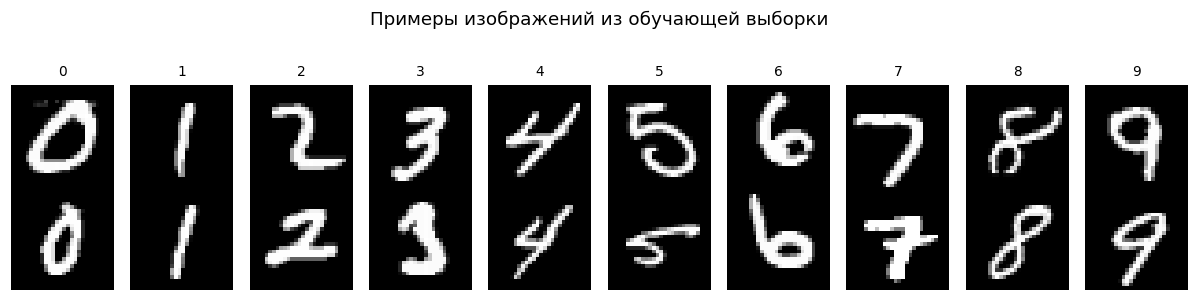

In [4]:
fig, axes = plt.subplots(2, 10, figsize=(11, 2.6))
for c in range(10):
    for row in range(2):
        j = np.flatnonzero(y_tr == c)[row]
        axes[row, c].imshow(X_tr[j], cmap='gray')
        axes[row, c].axis('off')
    axes[0, c].set_title(str(c), fontsize=9)
fig.suptitle('Примеры изображений из обучающей выборки', y=1.04)
plt.tight_layout()
plt.show()

Изображения 28 на 28 в градациях серого, десять классов, выборка сбалансирована.

## 3. Реализация метода ближайшего соседа

In [5]:
def distances(A, B, metric, chunk=25):
    """Матрица расстояний между строками A (запросы) и B (обучающая выборка)."""
    A = A.astype(np.float32)
    B = B.astype(np.float32)
    if metric == 'l2':
        d2 = (A ** 2).sum(1)[:, None] + (B ** 2).sum(1)[None, :] - 2 * A @ B.T
        return np.sqrt(np.maximum(d2, 0))
    if metric == 'cosine':
        An = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-12)
        Bn = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-12)
        return 1.0 - An @ Bn.T
    out = np.empty((len(A), len(B)), dtype=np.float32)
    for s in range(0, len(A), chunk):
        diff = np.abs(A[s:s + chunk, None, :] - B[None, :, :])
        if metric == 'l1':
            out[s:s + chunk] = diff.sum(-1)
        elif metric == 'linf':
            out[s:s + chunk] = diff.max(-1)
        else:
            raise ValueError(metric)
    return out


def knn_predict(dist, y_train, k, weighted):
    """Предсказание по готовой матрице расстояний."""
    nn = np.argpartition(dist, k - 1, axis=1)[:, :k]
    rows = np.arange(len(dist))[:, None]
    d = dist[rows, nn]
    order = np.argsort(d, axis=1)
    nn, d = nn[rows, order], d[rows, order]
    w = 1.0 / (d + 1e-9) if weighted else np.ones_like(d)
    votes = np.zeros((len(dist), 10), dtype=np.float64)
    np.add.at(votes, (rows, y_train[nn]), w)
    return votes.argmax(1)

Расстояния считаются один раз на конфигурацию, а перебор `k` и режима
голосования выполняется уже по готовой матрице: это главная экономия, поскольку
именно вычисление расстояний стоит дорого.

Для $L_2$ и косинусной меры используется разложение
$\lVert a - b\rVert^2 = \lVert a\rVert^2 + \lVert b\rVert^2 - 2\langle a, b\rangle$,
которое сводит задачу к матричному умножению. Для $L_1$ и $L_\infty$ такого
приёма нет, поэтому они считаются блоками по строкам запроса, чтобы не
переполнять память.

Проверим реализацию сверкой с `sklearn`.

In [6]:
from sklearn.neighbors import KNeighborsClassifier

flat_tr = X_tr.reshape(len(X_tr), -1) / 255.0
flat_te = X_te.reshape(len(X_te), -1) / 255.0

mine = knn_predict(distances(flat_te, flat_tr, 'l2'), y_tr, k=5, weighted=False)
ref = KNeighborsClassifier(n_neighbors=5, metric='euclidean').fit(flat_tr, y_tr).predict(flat_te)
print(f'совпадение с sklearn: {np.mean(mine == ref):.4f}')
print(f'accuracy собственной реализации: {np.mean(mine == y_te):.4f}')

совпадение с sklearn: 1.0000
accuracy собственной реализации: 0.8867


Предсказания совпадают с библиотечной реализацией, дальше используется собственная.

## 4. Модели зашумления

In [7]:
def uniform_noise(X, p, rng):
    """Каждый пиксель независимо с вероятностью p заменяется случайным значением."""
    X = X.copy()
    mask = rng.random(X.shape) < p
    X[mask] = rng.integers(0, 256, mask.sum(), dtype=np.uint8)
    return X


def blot_noise(X, size, rng):
    """Квадратный блок случайного положения заливается шумом."""
    X = X.copy()
    n, h, w = X.shape
    r0 = rng.integers(0, h - size + 1, n)
    c0 = rng.integers(0, w - size + 1, n)
    for i in range(n):
        X[i, r0[i]:r0[i] + size, c0[i]:c0[i] + size] = rng.integers(0, 256, (size, size))
    return X


def binarize(X, threshold=128):
    return (X > threshold).astype(np.uint8) * 255

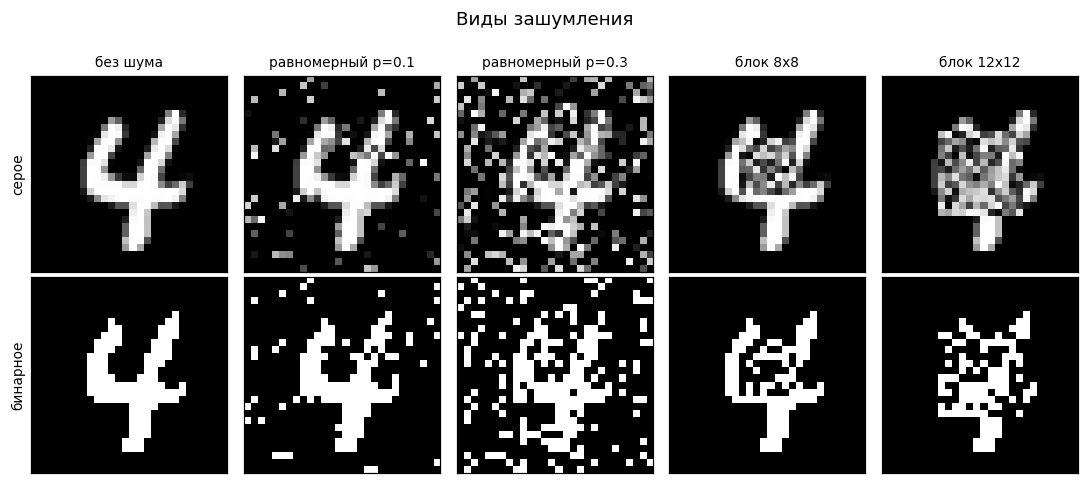

доля испорченных пикселей:
  без шума             0.000
  равномерный p=0.1    0.099
  равномерный p=0.3    0.300
  блок 8x8             0.081
  блок 12x12           0.183


In [8]:
conditions = {
    'без шума': lambda X, rng: X.copy(),
    'равномерный p=0.1': lambda X, rng: uniform_noise(X, 0.1, rng),
    'равномерный p=0.3': lambda X, rng: uniform_noise(X, 0.3, rng),
    'блок 8x8': lambda X, rng: blot_noise(X, 8, rng),
    'блок 12x12': lambda X, rng: blot_noise(X, 12, rng),
}

fig, axes = plt.subplots(2, 5, figsize=(10, 4.4))
for col, (name, f) in enumerate(conditions.items()):
    noisy = f(X_te[:1], np.random.default_rng(1))[0]
    axes[0, col].imshow(noisy, cmap='gray')
    axes[1, col].imshow(binarize(noisy), cmap='gray')
    axes[0, col].set_title(name, fontsize=9)
    for row in range(2):
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])
axes[0, 0].set_ylabel('серое', fontsize=9)
axes[1, 0].set_ylabel('бинарное', fontsize=9)
fig.suptitle('Виды зашумления', y=1.0)
plt.tight_layout()
plt.show()

print('доля испорченных пикселей:')
for name, f in conditions.items():
    noisy = f(X_te, np.random.default_rng(1))
    print(f'  {name:20s} {np.mean(noisy != X_te):.3f}')

Блок $12 \times 12$ портит $144/784 = 18\%$ пикселей, что близко к равномерному
шуму $p = 0.2$, но портит их подряд. Именно эту пару и интересно сравнивать.

## 5. Эксперименты

In [9]:
METRICS_GRAY = ['l1', 'l2', 'linf', 'cosine']
METRICS_BIN = ['l1', 'l2', 'linf', 'cosine']
KS = [1, 3, 5, 7, 9]

rows = []
t_start = time.time()

for repr_name, prep in [('серое', lambda X: X), ('бинарное', binarize)]:
    train = prep(X_tr).reshape(len(X_tr), -1).astype(np.float32) / 255.0
    metrics = METRICS_GRAY if repr_name == 'серое' else METRICS_BIN
    for cond_name, noise in conditions.items():
        noisy = noise(X_te, np.random.default_rng(20260905))
        test = prep(noisy).reshape(len(X_te), -1).astype(np.float32) / 255.0
        for metric in metrics:
            t0 = time.time()
            dist = distances(test, train, metric)
            t_dist = time.time() - t0
            for k in KS:
                for weighted in (False, True):
                    pred = knn_predict(dist, y_tr, k, weighted)
                    rows.append(dict(
                        representation=repr_name, condition=cond_name, metric=metric,
                        k=k, weighted=weighted,
                        accuracy=float(np.mean(pred == y_te)),
                        dist_time=round(t_dist, 2)))

print(f'посчитано {len(rows)} конфигураций за {time.time() - t_start:.0f} с')

посчитано 400 конфигураций за 43 с


In [10]:
import pandas as pd

df = pd.DataFrame(rows)
df.to_csv('results.csv', index=False)
print(df.shape)
df.head()

(400, 7)


,representation,condition,metric,k,weighted,accuracy,dist_time
0,серое,без шума,l1,1,False,0.900000,4.2
1,серое,без шума,l1,1,True,0.900000,4.2
2,серое,без шума,l1,3,False,0.883333,4.2
3,серое,без шума,l1,3,True,0.890000,4.2
4,серое,без шума,l1,5,False,0.876667,4.2


## 6. Результаты

### 6.1 Меры близости на чистых изображениях

In [11]:
clean = df[(df.condition == 'без шума') & (~df.weighted)]
pivot = clean.pivot_table(index=['representation', 'metric'], columns='k', values='accuracy')
pivot.round(3)

k                          1      3      5      7      9
representation metric                                   
бинарное       cosine  0.907  0.900  0.900  0.890  0.893
               l1      0.880  0.890  0.900  0.883  0.873
               l2      0.880  0.890  0.900  0.883  0.873
               linf    0.100  0.100  0.100  0.100  0.100
серое          cosine  0.910  0.910  0.900  0.903  0.893
               l1      0.900  0.883  0.877  0.880  0.873
               l2      0.930  0.907  0.887  0.893  0.873
               linf    0.560  0.527  0.553  0.543  0.563

На чистых изображениях лучший результат даёт $L_2$ в градациях серого при $k = 1$:
accuracy $0.930$. Косинусная мера идёт следом ($0.910$), $L_1$ отстаёт ($0.900$).
Бинаризация стоит около одного процента точности: $0.907$ против $0.930$.

Отдельно стоит $L_\infty$: $0.563$ на градациях серого и ровно $0.100$ на
бинарных, то есть уровень случайного угадывания. Причина в том, что для бинарных
изображений $\lvert x_j - z_j\rvert$ принимает только значения 0 и 1, поэтому
$L_\infty$ равно единице для любой пары изображений, отличающихся хотя бы одним
пикселем. Все расстояния совпадают, порядок соседей произволен, классификация
вырождается.

$L_1$ и $L_2$ на бинарных изображениях дают в точности одинаковую точность при
всех $k$ ($0.880$, $0.890$, $0.900$, $0.883$, $0.873$). Это подтверждает
теоретическое замечание из раздела 1: для векторов из нулей и единиц
$L_2^2 = L_1$, значит порядок соседей у обеих метрик один и тот же.

### 6.2 Устойчивость мер близости к шуму

In [12]:
best_k = df[~df.weighted].groupby(['representation', 'condition', 'metric'])['accuracy'].max()
table = best_k.unstack('metric').round(3)
table

metric                            cosine     l1     l2   linf
representation condition                                     
бинарное       без шума            0.907  0.900  0.900  0.100
               блок 12x12          0.757  0.800  0.800  0.100
               блок 8x8            0.873  0.867  0.867  0.100
               равномерный p=0.1   0.897  0.880  0.880  0.100
               равномерный p=0.3   0.880  0.877  0.877  0.100
серое          без шума            0.910  0.900  0.930  0.563
               блок 12x12          0.783  0.853  0.867  0.360
               блок 8x8            0.877  0.890  0.900  0.490
               равномерный p=0.1   0.903  0.900  0.923  0.407
               равномерный p=0.3   0.887  0.903  0.910  0.253

Равномерный шум почти не вредит: при $p = 0.3$ метрика $L_2$ на градациях серого
теряет всего $0.020$ ($0.930 \to 0.910$). Блочная порча вреднее при вдвое меньшей
доле испорченных пикселей: блок $12 \times 12$ портит $18.3\%$ пикселей против
$30\%$ у равномерного шума, но точность падает до $0.867$, то есть потеря втрое
больше.

Причина в том, что равномерный шум портит пиксели независимо, и суммирование по
784 координатам его в значительной мере усредняет. Блок же уничтожает связную
часть цифры целиком, и восстановить её по остальным пикселям нельзя.

Косинусная мера лучше всех держит равномерный шум на бинарных изображениях
($0.880$ при $p = 0.3$), но хуже всех переносит блок ($0.757$): она нормирует на
длину вектора, а блок эту длину резко меняет.

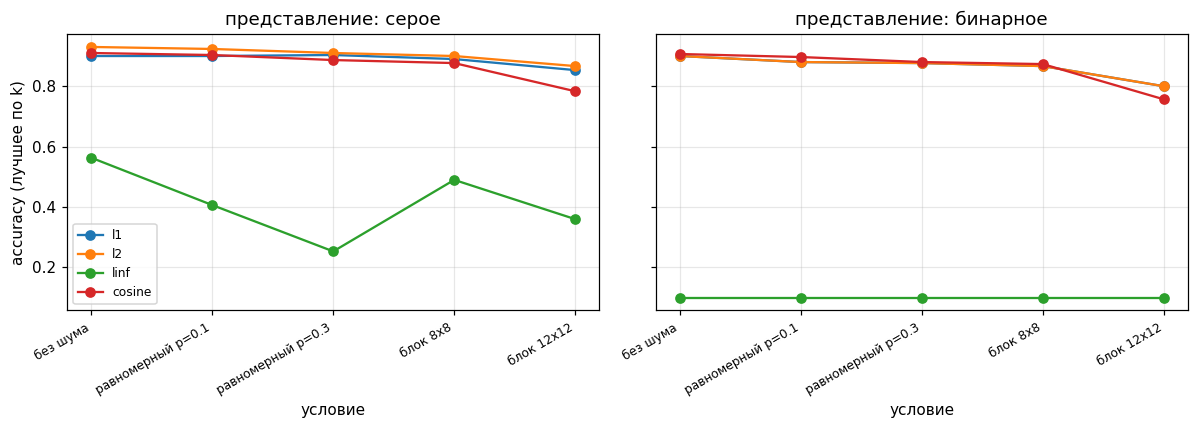

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
order = list(conditions.keys())
for ax, repr_name in zip(axes, ['серое', 'бинарное']):
    sub = df[(df.representation == repr_name) & (~df.weighted)]
    for metric in METRICS_GRAY:
        acc = [sub[(sub.condition == c) & (sub.metric == metric)].accuracy.max() for c in order]
        ax.plot(range(len(order)), acc, marker='o', label=metric)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=30, ha='right', fontsize=8)
    ax.set_title(f'представление: {repr_name}')
    ax.set_xlabel('условие')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('accuracy (лучшее по k)')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

Хорошо видно расслоение. Косинусная мера и $L_2$ идут почти вровень на чистых
данных, но по-разному реагируют на порчу: косинусная лучше держит равномерный
шум, $L_2$ - блочный. $L_1$ ведёт себя устойчиво, но всюду немного хуже $L_2$.
Линия $L_\infty$ на бинарном представлении - горизонталь на уровне $0.1$.

### 6.3 Зависимость от k

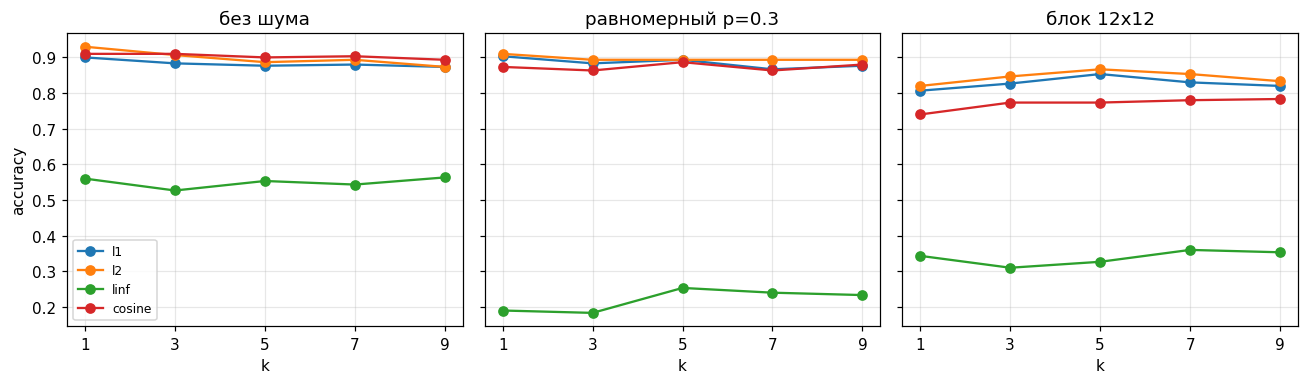

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, cond in zip(axes, ['без шума', 'равномерный p=0.3', 'блок 12x12']):
    sub = df[(df.representation == 'серое') & (df.condition == cond) & (~df.weighted)]
    for metric in METRICS_GRAY:
        s = sub[sub.metric == metric].sort_values('k')
        ax.plot(s.k, s.accuracy, marker='o', label=metric)
    ax.set_title(cond)
    ax.set_xlabel('k')
    ax.set_xticks(KS)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('accuracy')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

Наилучшее $k$ равно 1 или 3 почти во всех случаях: выборка из 2000 элементов на
10 классов достаточно плотная, а увеличение $k$ размывает границу между классами.
Исключение - $L_\infty$ на градациях серого, где точность от $k$ почти не зависит
и колеблется около $0.55$: метрика настолько неинформативна, что усреднение по
соседям ничего не добавляет.

### 6.4 Взвешенное голосование

In [15]:
cmp = df.pivot_table(index=['representation', 'condition', 'metric', 'k'],
                     columns='weighted', values='accuracy')
cmp['разность'] = cmp[True] - cmp[False]
print(f'взвешивание помогает в {(cmp["разность"] > 0).mean():.1%} конфигураций, '
      f'средний прирост {cmp["разность"].mean():+.4f}, '
      f'максимальный {cmp["разность"].max():+.4f}')
cmp.groupby('k')['разность'].mean().round(4)

взвешивание помогает в 49.0% конфигураций, средний прирост +0.0048, максимальный +0.0400


k
1    0.0000
3    0.0067
5    0.0057
7    0.0068
9    0.0049
Name: разность, dtype: float64

Взвешивание по расстоянию помогает в $49\%$ конфигураций при среднем приросте
$+0.005$. При $k = 1$ оно тождественно ничего не меняет: вес единственного соседа
сокращается в формуле голосования, и в таблице по $k$ стоит ровно $0.0000$. При
$k \ge 3$ прирост составляет $+0.005 \ldots +0.007$. Эффект есть, но он на
порядок меньше, чем разница между метриками.

### 6.5 Матрица ошибок лучшей конфигурации

лучшая конфигурация без шума: {'representation': 'серое', 'condition': 'без шума', 'metric': 'l2', 'k': np.int64(1), 'weighted': np.False_, 'accuracy': np.float64(0.93), 'dist_time': np.float64(0.02)}


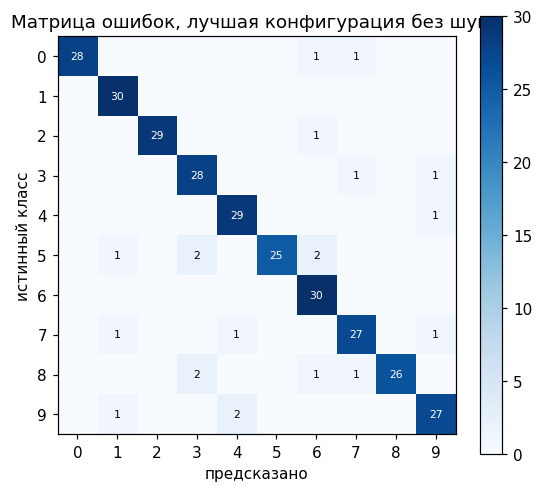

              precision    recall  f1-score   support

           0      1.000     0.933     0.966        30
           1      0.909     1.000     0.952        30
           2      1.000     0.967     0.983        30
           3      0.875     0.933     0.903        30
           4      0.906     0.967     0.935        30
           5      1.000     0.833     0.909        30
           6      0.857     1.000     0.923        30
           7      0.900     0.900     0.900        30
           8      1.000     0.867     0.929        30
           9      0.900     0.900     0.900        30

    accuracy                          0.930       300
   macro avg      0.935     0.930     0.930       300
weighted avg      0.935     0.930     0.930       300



In [16]:
from sklearn.metrics import confusion_matrix, classification_report

best = df.loc[df[df.condition == 'без шума'].accuracy.idxmax()]
print(f'лучшая конфигурация без шума: {dict(best)}')

prep = (lambda X: X) if best.representation == 'серое' else binarize
train = prep(X_tr).reshape(len(X_tr), -1).astype(np.float32) / 255.0
test = prep(X_te).reshape(len(X_te), -1).astype(np.float32) / 255.0
pred = knn_predict(distances(test, train, best.metric), y_tr, int(best.k), bool(best.weighted))

cm = confusion_matrix(y_te, pred)
fig, ax = plt.subplots(figsize=(5.2, 4.6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xlabel('предсказано')
ax.set_ylabel('истинный класс')
ax.set_title('Матрица ошибок, лучшая конфигурация без шума')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
for i in range(10):
    for j in range(10):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=7,
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.show()

print(classification_report(y_te, pred, digits=3))

Лучшая конфигурация: градации серого, $L_2$, $k = 1$, без весов, accuracy
$0.930$. Хуже всего распознаётся пятёрка (recall $0.833$), больше всего ложных
срабатываний у шестёрки (precision $0.857$) и тройки ($0.875$).

Самые частые путаницы: $9 \to 4$, $8 \to 3$, $5 \to 6$, $5 \to 3$ (по два случая
каждая). Все они устроены одинаково: цифры различаются небольшой связной
областью (замкнута ли петля, есть ли перемычка), а поэлементное сравнение
пикселей такой области никакого дополнительного веса не придаёт.

### 6.6 Время предсказания

In [17]:
timing = df.groupby('metric')['dist_time'].mean().sort_values()
print('среднее время вычисления матрицы расстояний 300 x 2000, с:')
print(timing.round(2).to_string())

среднее время вычисления матрицы расстояний 300 x 2000, с:
metric
l2        0.01
cosine    0.01
linf      2.04
l1        2.15


$L_2$ и косинусная мера считаются за $0.01$ с, $L_1$ и $L_\infty$ - за
$2.0 \ldots 2.2$ с, то есть в двести раз дольше. Разница целиком объясняется
реализацией: квадрат евклидова расстояния раскладывается в матричное умножение,
а $L_1$ и $L_\infty$ требуют явного поэлементного вычитания, которое нельзя
свести к BLAS.

Итог по всей работе: на растровых изображениях лучший выбор - $L_2$ по градациям
серого с $k = 1$; она же и самая быстрая. Бинаризация ухудшает точность и делает
$L_\infty$ полностью неработоспособной. Блочная порча опаснее равномерного шума
при вдвое меньшей доле испорченных пикселей.